In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neural_network import MLPClassifier

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
 

In [3]:
 
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 


In [4]:

# join features and targets into a single dataframe
df = pd.concat([X, y], axis=1)

# save the dataframe to a csv file
#df.to_csv('bank_marketing.csv', index=False)

In [5]:
# remove rows where poutcome is NaN but pdays is not -1
df = df[~((df['poutcome'].isna()) & (df['pdays'] != -1))]

# remove rows where education is NA
df = df[df['education'].notna()]

# remove rows where job is NA
df = df[df['job'].notna()]

# count number of rows where duration = 0
display(df[df['duration'] == 0].shape[0])

# remove rows where duration = 0
df = df[df['duration'] != 0]

# count number of rows where duration = 0
display(df[df['duration'] == 0].shape[0])

# remove pdays = -1

3

0

In [6]:
# filter out a subset of data where poutcome is not NaN
df_p = df[df['poutcome'].notna()]


# drop contact column
if 'contact' in df_p.columns:
    df_p = df_p.drop(columns=['contact'])

# check NAs in df_p
print(df_p.isna().sum())
print(df_p.shape)


age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64
(7907, 16)


In [7]:
# one hot encode categorical features
columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome', 'month', 'day_of_week']
df_t = pd.get_dummies(df_p[columns])

# # merge with numerical features
df_t = pd.concat([df_t, df_p[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']]], axis=1).reset_index(drop=True)




In [8]:
# save df_t to csv
df_t.to_csv('X.csv', index=False)
# save y to csv
df_p['y'].map({'yes': 1, 'no': 0}).to_csv('y.csv', index=False)


In [54]:

# read X and y from csv
X = pd.read_csv('X.csv')
y = pd.read_csv('y.csv')

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.2, random_state=42)

array([[  5.,   0.,   0., ...,   1., 301.,   1.],
       [ 17.,   0.,   1., ...,   3., 267.,   1.],
       [  6.,   1.,   0., ...,   6., 275.,   2.],
       ...,
       [ 21.,   0.,   0., ...,   4., 182.,   2.],
       [  6.,   0.,   0., ...,   1., 297.,   3.],
       [ 14.,   0.,   0., ...,   2., 209.,   3.]], shape=(6325, 45))

In [55]:

# logistic regression
model_1 = LogisticRegression()
model_1.fit(X_train_1, y_train_1);


/home/rongfei/WorkSpace/ds5220-group/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rongfei/WorkSpace/ds5220-group/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:

# predict on the testing set
y_pred_1 = model_1.predict(X_test_1)

# evaluate the model
print(classification_report(y_test_1, y_pred_1))
print(confusion_matrix(y_test_1, y_pred_1))

# encode no and yes to 0 and 1
y_pred_1 = np.where(y_pred_1 == "yes", 1, 0)
y_test_1 = np.where(y_test_1 == "yes", 1, 0)


auc_score = roc_auc_score(y_test_1, y_pred_1)
print(f"AUC score: {auc_score}")


              precision    recall  f1-score   support

           0       0.86      0.93      0.90      1252
           1       0.63      0.45      0.52       330

    accuracy                           0.83      1582
   macro avg       0.75      0.69      0.71      1582
weighted avg       0.82      0.83      0.82      1582

[[1165   87]
 [ 183  147]]
AUC score: nan


/home/rongfei/WorkSpace/ds5220-group/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [146]:


kf = KFold(n_splits=10, shuffle=True, random_state=42)

max_f1 = 0
min_report = None
min_confusion = None

param_grid = {
    'hidden_layer_sizes': [(4, 8), (2,4,8), (2,8)],
    'activation': ['relu'],
    'solver': ['adam'],
}

model_mlp = MLPClassifier()
grid_search = GridSearchCV(estimator=model_mlp, param_grid=param_grid, cv=kf, scoring='roc_auc')
grid_search.fit(X_train_1, y_train_1)


print(grid_search.best_params_)


/home/rongfei/WorkSpace/ds5220-group/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rongfei/WorkSpace/ds5220-group/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


{'activation': 'relu', 'hidden_layer_sizes': (4, 8), 'solver': 'adam'}


In [147]:
print(grid_search.best_score_)
print(confusion_matrix(y_test_1, grid_search.best_estimator_.predict(X_test_1)))

0.815135993947487
[[1057  195]
 [ 103  227]]


In [56]:
print(classification_report(y_test_1, grid_search.best_estimator_.predict(X_test_1)))

              precision    recall  f1-score   support

          no       0.90      0.89      0.89      1252
         yes       0.60      0.60      0.60       330

    accuracy                           0.83      1582
   macro avg       0.75      0.75      0.75      1582
weighted avg       0.83      0.83      0.83      1582



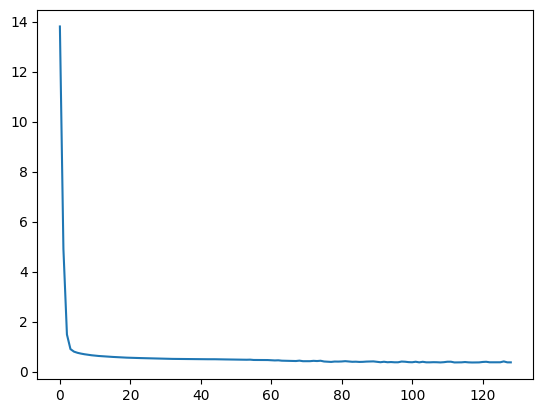

In [96]:
# print loss
plt.plot(grid_search.best_estimator_.loss_curve_)
plt.show()


In [41]:
def convert_to_numpy(X_train, y_train, X_test, y_test):
    X_train_np = X_train.to_numpy().astype(float)
    y_train_np = np.where(y_train.to_numpy() == "yes", 1.0, 0.0).reshape(-1, 1)
    X_test_np = X_test.to_numpy().astype(float)
    y_test_np = np.where(y_test.to_numpy() == "yes", 1.0, 0.0).reshape(-1, 1)
    
    return X_train_np, y_train_np, X_test_np, y_test_np

X_train_1_np, y_train_1_np, X_test_1_np, y_test_1_np = convert_to_numpy(X_train_1, y_train_1, X_test_1, y_test_1)

In [34]:
# autoreload mlp.py


In [43]:
print(X_train_1_np.shape)

(6325, 45)


In [44]:
%load_ext autoreload
%autoreload 2

from sklearn.metrics import roc_auc_score
from mlp import MLP

arch = [[45, 256, 1], [45, 164, 1], [45, 128, 1], [45, 64, 1]]

kf_5 = KFold(n_splits=5, shuffle=True, random_state=42)

best_auc = 0
best_params = None
for arch in arch:
    total_roc_auc = 0
    for i, (train_index, test_index) in enumerate(kf_5.split(df_t)):

        X = df_t.drop(columns=['y']).to_numpy().astype(float)
        y = df_t['y'].map({'yes': 1, 'no': 0}).to_numpy().astype(float)

        mlp = MLP(arch)
        losses =mlp.train(X[train_index], y[train_index], learning_rate=0.001, n_epochs=100)

        y_pred_1 = mlp.predict(X[test_index])
        auc_score = roc_auc_score(y[test_index], y_pred_1)
        total_roc_auc += auc_score
    
    if total_roc_auc/5 > best_auc:
        best_auc = total_roc_auc/5
        best_params = arch



Epoch 100/100, Loss: 2.0872
Epoch 100/100, Loss: 0.6791
Epoch 100/100, Loss: 0.9984
Epoch 100/100, Loss: 1.4874
Epoch 100/100, Loss: 1.2435
Epoch 100/100, Loss: 1.1674
Epoch 100/100, Loss: 1.1258
Epoch 100/100, Loss: 1.8135
Epoch 100/100, Loss: 0.7947
Epoch 100/100, Loss: 0.8652
Epoch 100/100, Loss: 1.2871
Epoch 100/100, Loss: 1.0364
Epoch 100/100, Loss: 1.3339
Epoch 100/100, Loss: 1.3849
Epoch 100/100, Loss: 0.8520
Epoch 100/100, Loss: 4.5206
Epoch 100/100, Loss: 3.5166
Epoch 100/100, Loss: 1.2454
Epoch 100/100, Loss: 1.2168
Epoch 100/100, Loss: 3.3077


In [45]:
print(f"Best ROC AUC: {best_auc}")
print(f"Best params: {best_params}")


Best ROC AUC: 0.7320192811507592
Best params: [45, 256, 1]


In [46]:

mlp = MLP(best_params)
losses = mlp.train(X_train_1_np, y_train_1_np, learning_rate=0.001, n_epochs=100)

Epoch 100/100, Loss: 0.8876


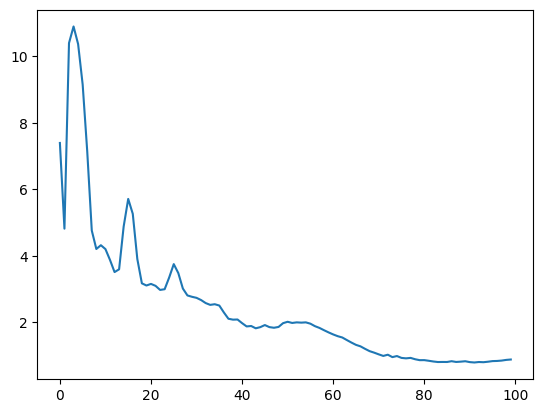

In [47]:
from matplotlib import pyplot as plt
# plot the losses
plt.plot(losses)
plt.show()

In [48]:

# compute the accuracy of the model
y_train_pred_1 = mlp.predict(X_train_1_np)
# convert y_pred_1 to 0 and 1
y_train_pred_1 = np.where(y_train_pred_1 > 0.5, 1, 0)
accuracy = np.mean(y_train_pred_1 == y_train_1_np)
print(f"Accuracy: {accuracy}")


Accuracy: 0.7418181818181818


In [49]:
# compute the accuracy of the model on the testing set
y_test_pred_1 = mlp.predict(X_test_1_np)
# convert y_pred_1 to 0 and 1
y_test_pred_1 = np.where(y_test_pred_1 > 0.5, 1, 0)
accuracy = np.mean(y_test_pred_1 == y_test_1_np)
print(f"Accuracy: {accuracy}")



Accuracy: 0.7572692793931732


In [50]:
print(classification_report(y_test_1_np, y_test_pred_1))

              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85      1252
         1.0       0.39      0.28      0.32       330

    accuracy                           0.76      1582
   macro avg       0.60      0.58      0.59      1582
weighted avg       0.73      0.76      0.74      1582

